<center style="padding:1rem 0;">
    <h1 style="font-size: 4rem;">IA - Deep Learning</h1>
    <h2 style="font-size: 2rem;">Livrable 1 - Prétraitement</h2>
    <h5 style="font-size: 1rem;"><i>Thomas VINET, Hugo HELM, Alban GODIER</i></h5>
</center>

<img src="assets/cesi.png" style="position:absolute;right:2rem;top:5.5rem;width:10rem;background:#fee237;"/>

# Import des librairies

Installer les dépendances :

```bash
pip install -r requirements.txt
```

In [1]:
from __future__ import annotations

# Typing
from typing import Dict

# Mathematics
import math as math

# Charts
import matplotlib.pyplot as plt
import seaborn as sns

# Data management and processing
import pandas as pd
import numpy as np

# Rendering
import ipywidgets as widgets
from IPython.display import display

# Lib
from lib.dataset import Dataset

# Options
import warnings
pd.set_option('display.max_columns', None)
warnings.filterwarnings("ignore")
np.random.seed(42)

# Préparation des données (Livrable 1)

1. Chargement et compréhension initiale du dataset
2. Séparation entre variable cible et variables explicatives
3. Scission du dataset (train/test/validation)
4. Typage des variables
5. Nettoyage des doublons et gestion des valeurs manquantes
6. Analyse exploratoire quantitative
7. Analyse exploratoire qualitative (EDA visuelle)
8. Choix et implémentation d’une méthode de normalisation
9. Sauvegarde du jeu de données nettoyé

# Analyse du dataset

In [2]:
dataset = Dataset.from_csv('dataset/diabetes_binary_health_indicators_BRFSS2015.csv', target='Diabetes_binary')
dataset_quantitative = Dataset(dataset.data[['BMI', 'MentHlth', 'PhysHlth']], target=dataset.target)
dataset_qualitative = Dataset(
    dataset.data[
        [
            "Diabetes_binary",
            "HighBP",
            "HighChol",
            "CholCheck",
            "Smoker",
            "Stroke",
            "HeartDiseaseorAttack",
            "PhysActivity",
            "Fruits",
            "Veggies",
            "HvyAlcoholConsump",
            "AnyHealthcare",
            "NoDocbcCost",
            "DiffWalk",
            "Sex",
            "Age",
            "Education",
            "Income",
        ]
    ],
    target=dataset.data,
)

In [3]:
# Info
dataset.info()

,Column,Non-Null Count,Data Type
0,Diabetes_binary,253680,float64
1,HighBP,253680,float64
2,HighChol,253680,float64
3,CholCheck,253680,float64
4,BMI,253680,float64
5,Smoker,253680,float64
6,Stroke,253680,float64
7,HeartDiseaseorAttack,253680,float64
8,PhysActivity,253680,float64
9,Fruits,253680,float64


In [4]:
# Head
dataset.head()

,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,AnyHealthcare,NoDocbcCost,GenHlth,MentHlth,PhysHlth,DiffWalk,Sex,Age,Education,Income
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,5.0,18.0,15.0,1.0,0.0,9.0,4.0,3.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,3.0,0.0,0.0,0.0,0.0,7.0,6.0,1.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,5.0,30.0,30.0,1.0,0.0,9.0,4.0,8.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,2.0,0.0,0.0,0.0,0.0,11.0,3.0,6.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,2.0,3.0,0.0,0.0,0.0,11.0,5.0,4.0


## Typage des variables

### Types de variables possibles

Il existe 4 sous-types de variables possibles pour les données :
- Qualitatives (catégorielles) :
  - Nominales : Aucune hiérarchie entre les valeurs.
  - Ordinales : Il existe un ordre logique, mais l'écart entre les valeurs n'est pas quantifiable.
- Quantitatives (Numériques) :
  - Discrètes : Des nombres entiers, souvent issus d'un comptage.
  - Continues : Des valeurs qui peuvent prendre une infinité de possibilités dans un intervalle. 

### Typage du dataset

| Nom                  | Type                   | Interval de définition  | Description                                                                                                                                                                                                                            |
| -------------------- | ---------------------- | ----------------------- | -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- |
| **Diabetes_binary**  | Qualitative Nominale   | $[0,1] \in \mathbb{N}$  | La personne est diabétique ou non. La valeur est à l'origine une valeur qualitative nominale (Yes/No) qui a été convertie en binaire. Cette valeur est également notre cible pour la prédiction. 0 : non, 1 : oui                      |
| HighBP               | Qualitative Nominale   | $[0,1] \in \mathbb{N}$  | La personne a une pression artérielle élevée ou non. La valeur est à l'origine une valeur qualitative nominale (Yes/No) qui a été convertie en binaire. 0 : non, 1 : oui                                                               |
| HighChol             | Qualitative Nominale   | $[0,1] \in \mathbb{N}$  | La personne a un taux de cholestérol élevé ou non. La valeur est à l'origine une valeur qualitative nominale (Yes/No) qui a été convertie en binaire. 0 : non, 1 : oui                                                                 |
| CholCheck            | Qualitative Nominale   | $[0,1] \in \mathbb{N}$  | La personne a fait vérifier son taux de cholestérol au cours des 5 dernières années. La valeur est à l'origine une valeur qualitative nominale (Yes/No) qui a été convertie en binaire. 0 : non, 1 : oui                               |
| BMI                  | Quantitative Continue  | $\mathbb{R}$            | Indice de masse corporelle de la personne, calculé à partir de son poids et de sa taille.                                                                                                                                              |
| Smoker               | Qualitative Nominale   | $[0,1] \in \mathbb{N}$  | La personne est fumeuse ou non. On entend par fumeuse une personne qui a fumé au moins 100 cigarettes dans sa vie. La valeur est à l'origine une valeur qualitative nominale (Yes/No) qui a été convertie en binaire. 0 : non, 1 : oui |
| Stroke               | Qualitative Nominale   | $[0,1] \in \mathbb{N}$  | La personne a déjà eu un AVC (accident vasculaire cérébral) ou non. La valeur est à l'origine une valeur qualitative nominale (Yes/No) qui a été convertie en binaire. 0 : non, 1 : oui                                                |
| HeartDiseaseorAttack | Qualitative Nominale   | $[0,1] \in \mathbb{N}$  | La personne a déjà eu une maladie cardiaque ou une crise cardiaque (infarctus du myocarde) ou non. La valeur est à l'origine une valeur qualitative nominale (Yes/No) qui a été convertie en binaire. 0 : non, 1 : oui                 |
| PhysActivity         | Qualitative Nominale   | $[0,1] \in \mathbb{N}$  | La personne a eu une activité physique dans les 30 dernier jours (hors travail). Transformation d'une variable qualitative. 0 : non, 1 : oui                                                                                           |
| Fruits               | Qualitative Nominale   | $[0,1] \in \mathbb{N}$  | La personne consomme un fruit au moins une fois par jour. Transformation d'une variable qualitative. 0 : non, 1 : oui                                                                                                                  |
| Veggies              | Qualitative Nominale   | $[0,1] \in \mathbb{N}$  | La personne consomme un légume au moins une fois par jour. Transformation d'une variable qualitative. 0 : non, 1 : oui                                                                                                                 |
| HvyAlcoholConsump    | Qualitative Nominale   | $[0,1] \in \mathbb{N}$  | La personne a une grosse consommation d'alcool. (homme : $\ge$ 14 verres par semaine ; femme : $\ge$ 7 verres par semaine) . Transformation d'une variable qualitative. 0 : non, 1 : oui.                                              |
| AnyHealthcare        | Qualitative Nominale   | $[0,1] \in \mathbb{N}$  | La personne a une couverture santé (assurance maladie, HMO). Transformation d'une variable qualitative. 0 : non, 1 : oui.                                                                                                              |
| NoDocbcCost          | Qualitative Nominale   | $[0,1] \in \mathbb{N}$  | Il est arrivé que la personne refuse de voir une docteur pour des raisons de coûts dans les 12 derniers mois. 0 : non, 1 : oui.                                                                                                        |
| GenHlth              | Qualitative Ordinale   | $[1,5] \in \mathbb{N}$  | Estimation de l'état de santé de la personne (par elle-même) sur une échelle de 1 à 5. 1 : excellent, 2 : very good, 3 : good, 4 : moyen, 5 : pauvre.                                                                                  |
| MentHlth             | Quantitative Discrète | $[0,30] \in \mathbb{N}$ | Nombre de jours de mauvaise santé mentale de la personne (jugé par elle-même) durant les 30 derniers jours.                                                                                                                            |
| PhysHlth             | Quantitative Discrète | $[0,30] \in \mathbb{N}$ | Nombre de jours de mauvaise santé physique de la personne (jugé par elle-même) durant les 30 derniers jours.                                                                                                                           |
| DiffWalk             | Qualitative Nominale   | $[0,1] \in \mathbb{N}$  | Difficulté pour la personne à marcher ou à monter les escaliers. 0 : non, 1 : oui.                                                                                                                                                     |
| Sex                  | Qualitative Nominale   | $[0,1] \in \mathbb{N}$  | Genre de la personne. 0 : Femme, 1 : Homme                                                                                                                                                                                             |
| Age                  | Qualitative Ordinale   | $[1,13] \in \mathbb{N}$ | Catégorie d'âge. Correspond à un niveau entre 1 et 14 sachant que le niveau 14 n'est pas représenté dans le jeu de données. Les différents niveaux sont détaillés en annexe.                                                           |
| Education            | Qualitative Ordinale   | $[1,6] \in \mathbb{N}$  | Niveau d'éducation. Correspond à un niveau entre 1 et 6.                                                                                                                                                                               |
| Income               | Qualitative Ordinale   | $[1,8] \in \mathbb{N}$  | Catégorie de revenu. Correspond à un niveau entre 1 et 8. Les différents niveaux son détaillés en annexe.                                                                                                                              |

## Analyse des données

Le dataset contient 253 680 lignes et 22 colonnes. Les variables sont principalement de type qualitatif nominal, avec quelques variables quantitatives discrètes et continues, ainsi que des variables qualitatives ordinales.

### Analyse exploratoire quantitative

Dans cette section, nous allons analyser les données de manière quantitative afin de mieux comprendre leur distribution et leurs caractéristiques statistiques. Nous allons notamment calculer des mesures de tendance centrale, de dispersion, et d'autres statistiques descriptives pour chaque variable du dataset.

Nous pouvons remarquer que les 3 colonnes quantitatives (BMI, MentHlth, PhysHlth) ont des distributions différentes. Le BMI a une moyenne de 28.9 et une médiane de 28.1, ce qui indique que la distribution est légèrement asymétrique vers la droite. Les variables MentHlth et PhysHlth ont des moyennes de 3.5 et 3.4 respectivement, avec des médianes de 0, ce qui suggère que la plupart des personnes n'ont pas de jours de mauvaise santé mentale ou physique. (Onglet "Statistiques descriptives")

Ensuite, nous remarquons que aucune des colonnes ne contient de valeurs manquantes, ce qui est un bon point pour la qualité des données. (Onglet "Valeurs manquantes") Cependant, nous pouvons observer la présence de valeurs aberrantes dans les colonnes quantitatives, notamment dans le BMI où il y a des valeurs très élevées (max 97.5) qui pourraient être des erreurs de saisie ou des cas extrêmes. (Onglet "Valeurs aberrantes")

In [5]:
dataset_quantitative.describe()

,BMI,MentHlth,PhysHlth
count,253680.000000,253680.000000,253680.000000
mean,28.382364,3.184772,4.242081
std,6.608694,7.412847,8.717951
min,12.000000,0.000000,0.000000
25%,24.000000,0.000000,0.000000
50%,27.000000,0.000000,0.000000
75%,31.000000,2.000000,3.000000
max,98.000000,30.000000,30.000000


In [6]:
dataset_quantitative.get_missing_values()

BMI         0
MentHlth    0
PhysHlth    0
dtype: int64

In [7]:
dataset_quantitative.get_outliers()

BMI          2963
MentHlth    12697
PhysHlth        0
dtype: int64

### Analyse Exploratoire Qualitative (EDA visuelle)

Dans cette section, nous allons analyser les données de manière qualitative à l'aide de visualisations graphiques. Nous allons notamment examiner la distribution des variables à l'aide d'histogrammes et de boîtes à moustaches (boxplots) pour identifier les tendances, les asymétries, et les éventuelles valeurs aberrantes.

Nous pouvons observer que les variables qualitatives nominales ont des distributions très déséquilibrées, avec une majorité de personnes n'ayant pas les caractéristiques suivantes : taux de cholestérol pas vérifié, AVC, maladie cardiaque, activité physique, consommation de fruits et légumes, grosse consommation d'alcool, couverture santé, refus de voir un docteur pour des raisons de coût, difficulté à marcher, age. (Onglet "Distribution des variables (Histogrammes)")

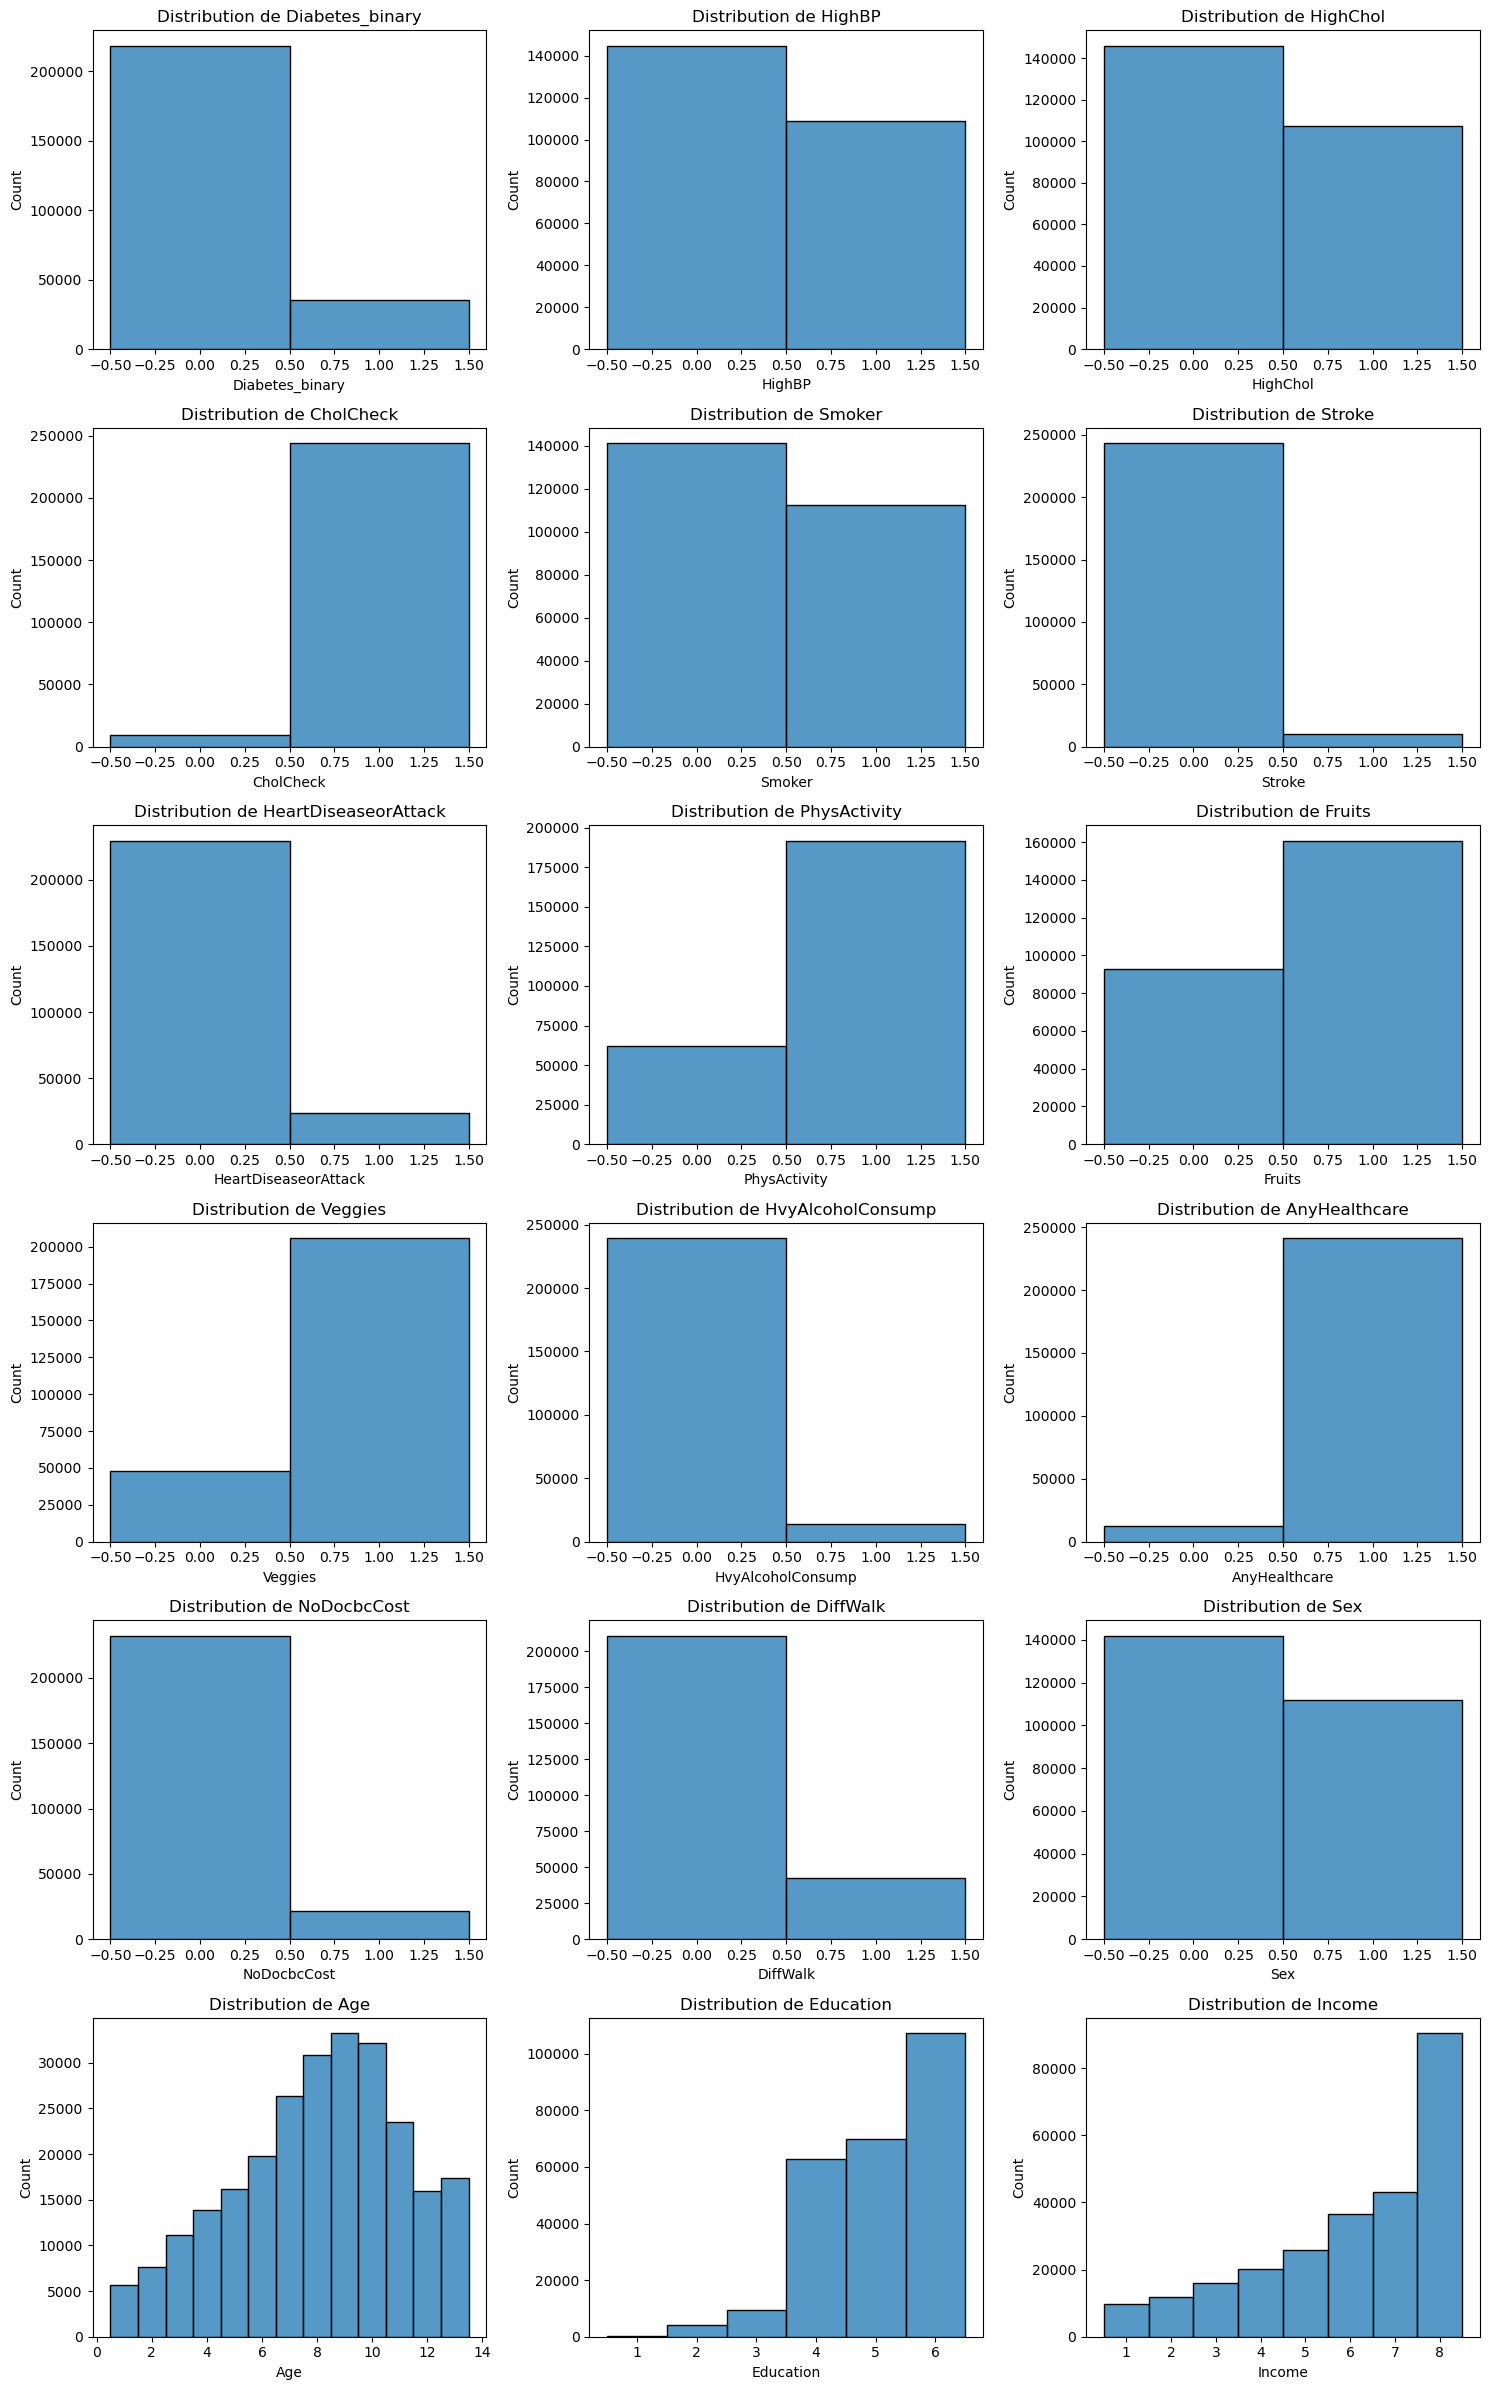

In [8]:
dataset_qualitative.draw_distributions()

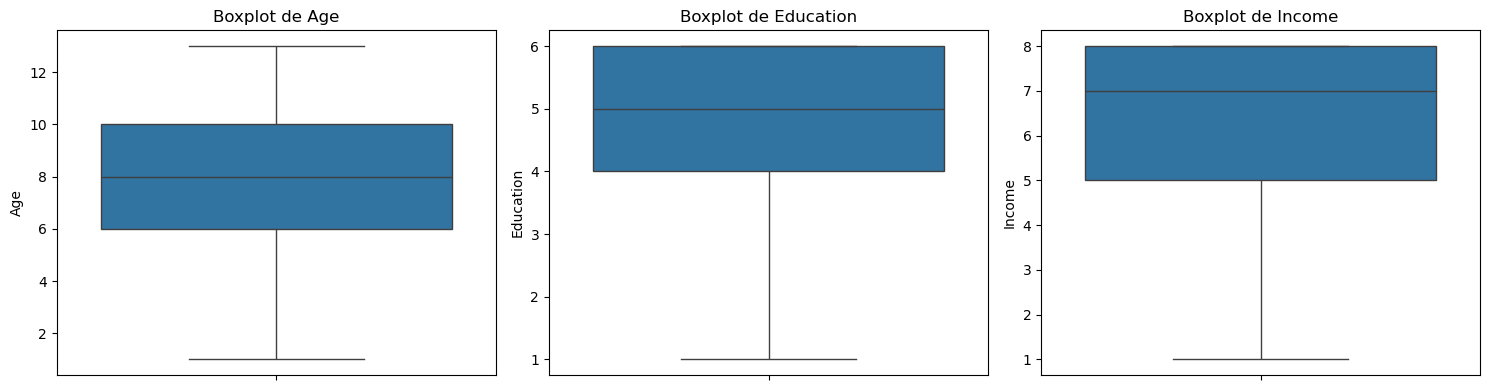

In [9]:
dataset_qualitative.draw_boxplots(['Age', 'Education','Income'])

## Gestion des doublons

In [10]:
duplicate_count = dataset.get_duplicate_count()
row_count = dataset.get_row_count()

print(f"Nombre de lignes dupliqués : {duplicate_count} / {row_count}")
print(f"Pourcentage de lignes dupliquées : {duplicate_count / row_count * 100:.2f} %")

dataset.drop_duplicates()

row_count = dataset.get_row_count()
print("\nDoublons supprimés")
print(f"Nombre de ligne après suppression : {row_count}")

Nombre de lignes dupliqués : 24206 / 253680
Pourcentage de lignes dupliquées : 9.54 %

Doublons supprimés
Nombre de ligne après suppression : 229474


## Présélection des variables importantes

Certaines variables proviennent de questionnaires et reposent donc sur des réponses subjectives. Elles sont susceptibles de refléter des biais liés aux perceptions individuelles, c’est pourquoi nous avons choisi de ne pas les garder :
- GenHlth
- MentHlth 
- PhysHlth

Certaines variables ne correspondent pas à des données de santé et peuvent entraîner un biais dans les prédictions :
- Education
- Income

In [11]:
dataset.drop([
    'GenHlth',
    'MentHlth',
    'PhysHlth',
    'Education',
    'Income'
], inplace=True)

In [12]:
dataset.info()

,Column,Non-Null Count,Data Type
0,Diabetes_binary,229474,float64
1,HighBP,229474,float64
2,HighChol,229474,float64
3,CholCheck,229474,float64
4,BMI,229474,float64
5,Smoker,229474,float64
6,Stroke,229474,float64
7,HeartDiseaseorAttack,229474,float64
8,PhysActivity,229474,float64
9,Fruits,229474,float64


In [13]:
dataset.describe()

,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,AnyHealthcare,NoDocbcCost,DiffWalk,Sex,Age
count,229474.000000,229474.000000,229474.000000,229474.000000,229474.000000,229474.00000,229474.000000,229474.000000,229474.000000,229474.000000,229474.000000,229474.000000,229474.000000,229474.000000,229474.000000,229474.000000,229474.000000
mean,0.152945,0.454343,0.441640,0.959481,28.687507,0.46580,0.044816,0.103336,0.733042,0.612675,0.794587,0.060791,0.946011,0.092921,0.185751,0.439087,8.085068
std,0.359936,0.497912,0.496584,0.197173,6.789204,0.49883,0.206899,0.304398,0.442371,0.487140,0.404004,0.238947,0.225996,0.290323,0.388906,0.496277,3.094451
min,0.000000,0.000000,0.000000,0.000000,12.000000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.000000
25%,0.000000,0.000000,0.000000,1.000000,24.000000,0.00000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,6.000000
50%,0.000000,0.000000,0.000000,1.000000,27.000000,0.00000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,0.000000,8.000000
75%,0.000000,1.000000,1.000000,1.000000,32.000000,1.00000,0.000000,0.000000,1.000000,1.000000,1.000000,0.000000,1.000000,0.000000,0.000000,1.000000,10.000000
max,1.000000,1.000000,1.000000,1.000000,98.000000,1.00000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,13.000000


## Gestion des valeurs manquantes

In [14]:
dataset.get_missing_values()

Diabetes_binary         0
HighBP                  0
HighChol                0
CholCheck               0
BMI                     0
Smoker                  0
Stroke                  0
HeartDiseaseorAttack    0
PhysActivity            0
Fruits                  0
Veggies                 0
HvyAlcoholConsump       0
AnyHealthcare           0
NoDocbcCost             0
DiffWalk                0
Sex                     0
Age                     0
dtype: int64

Aucune valeur n'est manquante.

## Gestion des valeurs catégorielles 

Il existe diverses méthodes de gestion des valeurs catégorielles en fonction des types de données concernées et d'autres facteurs : 
- One Hot Encoder : chaque colonne devient une colonne binaire. Cette méthode à l'avantage de ne pas dépendre d'un ordre entre les catégories, cependant, elle peut entraîner une augmentation significative du nombre de colonnes et donc limiter les performances de l'entraînement.
- Ordinal Encoder : chaque catégorie est remplacée par une valeur numérique ordonnée ou non. Cette méthode fonctionne bien dans le cas de catégories ordonnées (comme grand, moyen petit) mais peut entraîner une mauvaise interprétation du réseau de neurones dans les autres cas.

Rappel des colonnes catégorielles : 
- HighBP (0 ou 1)
- HighChol (0 ou 1)
- CholCheck (0 ou 1)
- Smoker (0 ou 1)
- Stroke (0 ou 1)
- HeartDiseaseorAttack (0 ou 1)
- PhysActivity (0 ou 1)
- Fruits (0 ou 1)
- Veggies (0 ou 1)
- HvyAlcoholConsump (0 ou 1)
- AnyHealthcare (0 ou 1)
- NoDocbcCost (0 ou 1)
- DiffWalk (0 ou 1)
- Sex (0 ou 1)
- Age (1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12 ou 13)
- Education (1, 2, 3, 4, 5 ou 6)
- Income (1, 2, 3, 4, 5, 6, 7 ou 8)

Les variables catégorielles ne nécessitent pas de gestion particulière, car elles sont déjà représentées par des valeurs numériques. Les dernières colonnes ('Age', 'Education', 'Income') sont déjà des variables qualitatives ordinales donc il n'est pas grave que le réseau de neurones interprète un ordre dans les catégories. Pour les autres variables (les variables binaires), le réseau de neurones ne peut pas interpréter un ordre.

In [15]:
dataset.info()

,Column,Non-Null Count,Data Type
0,Diabetes_binary,229474,float64
1,HighBP,229474,float64
2,HighChol,229474,float64
3,CholCheck,229474,float64
4,BMI,229474,float64
5,Smoker,229474,float64
6,Stroke,229474,float64
7,HeartDiseaseorAttack,229474,float64
8,PhysActivity,229474,float64
9,Fruits,229474,float64


In [16]:
dataset.head()

,Diabetes_binary,HighBP,HighChol,CholCheck,BMI,Smoker,Stroke,HeartDiseaseorAttack,PhysActivity,Fruits,Veggies,HvyAlcoholConsump,AnyHealthcare,NoDocbcCost,DiffWalk,Sex,Age
0,0.0,1.0,1.0,1.0,40.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,1.0,0.0,1.0,0.0,9.0
1,0.0,0.0,0.0,0.0,25.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,7.0
2,0.0,1.0,1.0,1.0,28.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,1.0,1.0,0.0,9.0
3,0.0,1.0,0.0,1.0,27.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,11.0
4,0.0,1.0,1.0,1.0,24.0,0.0,0.0,0.0,1.0,1.0,1.0,0.0,1.0,0.0,0.0,0.0,11.0


## Valeurs aberrantes

> **Pourquoi traiter les valeurs aberrantes :**
> 
> Le traitement des valeurs aberrantes est important, car les observations extrêmes peuvent biaiser les modèles.
> 
> Elles introduisent du bruit, favorisent le surapprentissage et dégradent la capacité de généralisation. 
> De plus, elles peuvent perturber les étapes de prétraitement comme la normalisation.
> 
> Un traitement adapté permet ainsi d’améliorer la robustesse, la stabilité et les performances globales du modèle.

<br />

> **Colonne à traiter :**
> 
> Comme les colonnes qualitatives ne peuvent pas avoir de valeurs aberrantes, les valeurs aberrantes des colonnes quantitative sont les seules à traiter.
>
> Notre seule colonne quantitative est BMI, nous ne traiterons donc que BMI pour rendre la distribution de cette colonne normale.

### Méthodes de détection des valeurs aberrantes

Les méthodes statistiques pour détecter les valeurs aberrantes dans un dataset sont les suivantes :

| Nom                       | Méthode                                                                                                                                                                                      | Avantages                                                      | Désavantages                                          | Cas d'utilisation                                                            |
| ------------------------- | -------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------------- | -------------------------------------------------------------- | ----------------------------------------------------- | ---------------------------------------------------------------------------- |
| Z-score                   | Une valeur est considérée aberrante si $\|z\| > 3$                                                                                                                                           | Standardise les données, sensible aux anomalies extrêmes       | Sensible aux données non normales                     | Pour des données : suivant une distribution normale ;                        |
| IQR (Interquartile Range) | Une valeur est considérée aberrante si la valeur est $x>Q3+1.5\times IQR$ ou $x<Q1-1.5\times IQR$. Avec $IQR$ : l'écart entre $Q1$ et $Q3$ ($50\%$ des données)                              | Indépendant de la moyenne, robustes faces aux valeurs extrêmes | Moins sensibles aux anomalies proches des quartiles ; | Pour des données : asymétrique ; avec beaucoup d'outliers ; non normalisées. |
| Écart-type                | Une valeur est considérée aberrante si elle est à un certain nombre d'écart type ($\sigma$) de la moyenne : $x>\mu+k\sigma$ ou $x<\mu-k\sigma$ ($\mu$ : moyenne, $k$ : seuil souvent 2 ou 3) | Bon pour des distributions symétriques                         | Dépendant de la distribution                          | Pour des données : gaussiennes (distribution normale) ; avec peu d'outliers  |

Pour choisir la méthode de détection des valeurs aberrantes, on étudie d'abord la distribution des données.

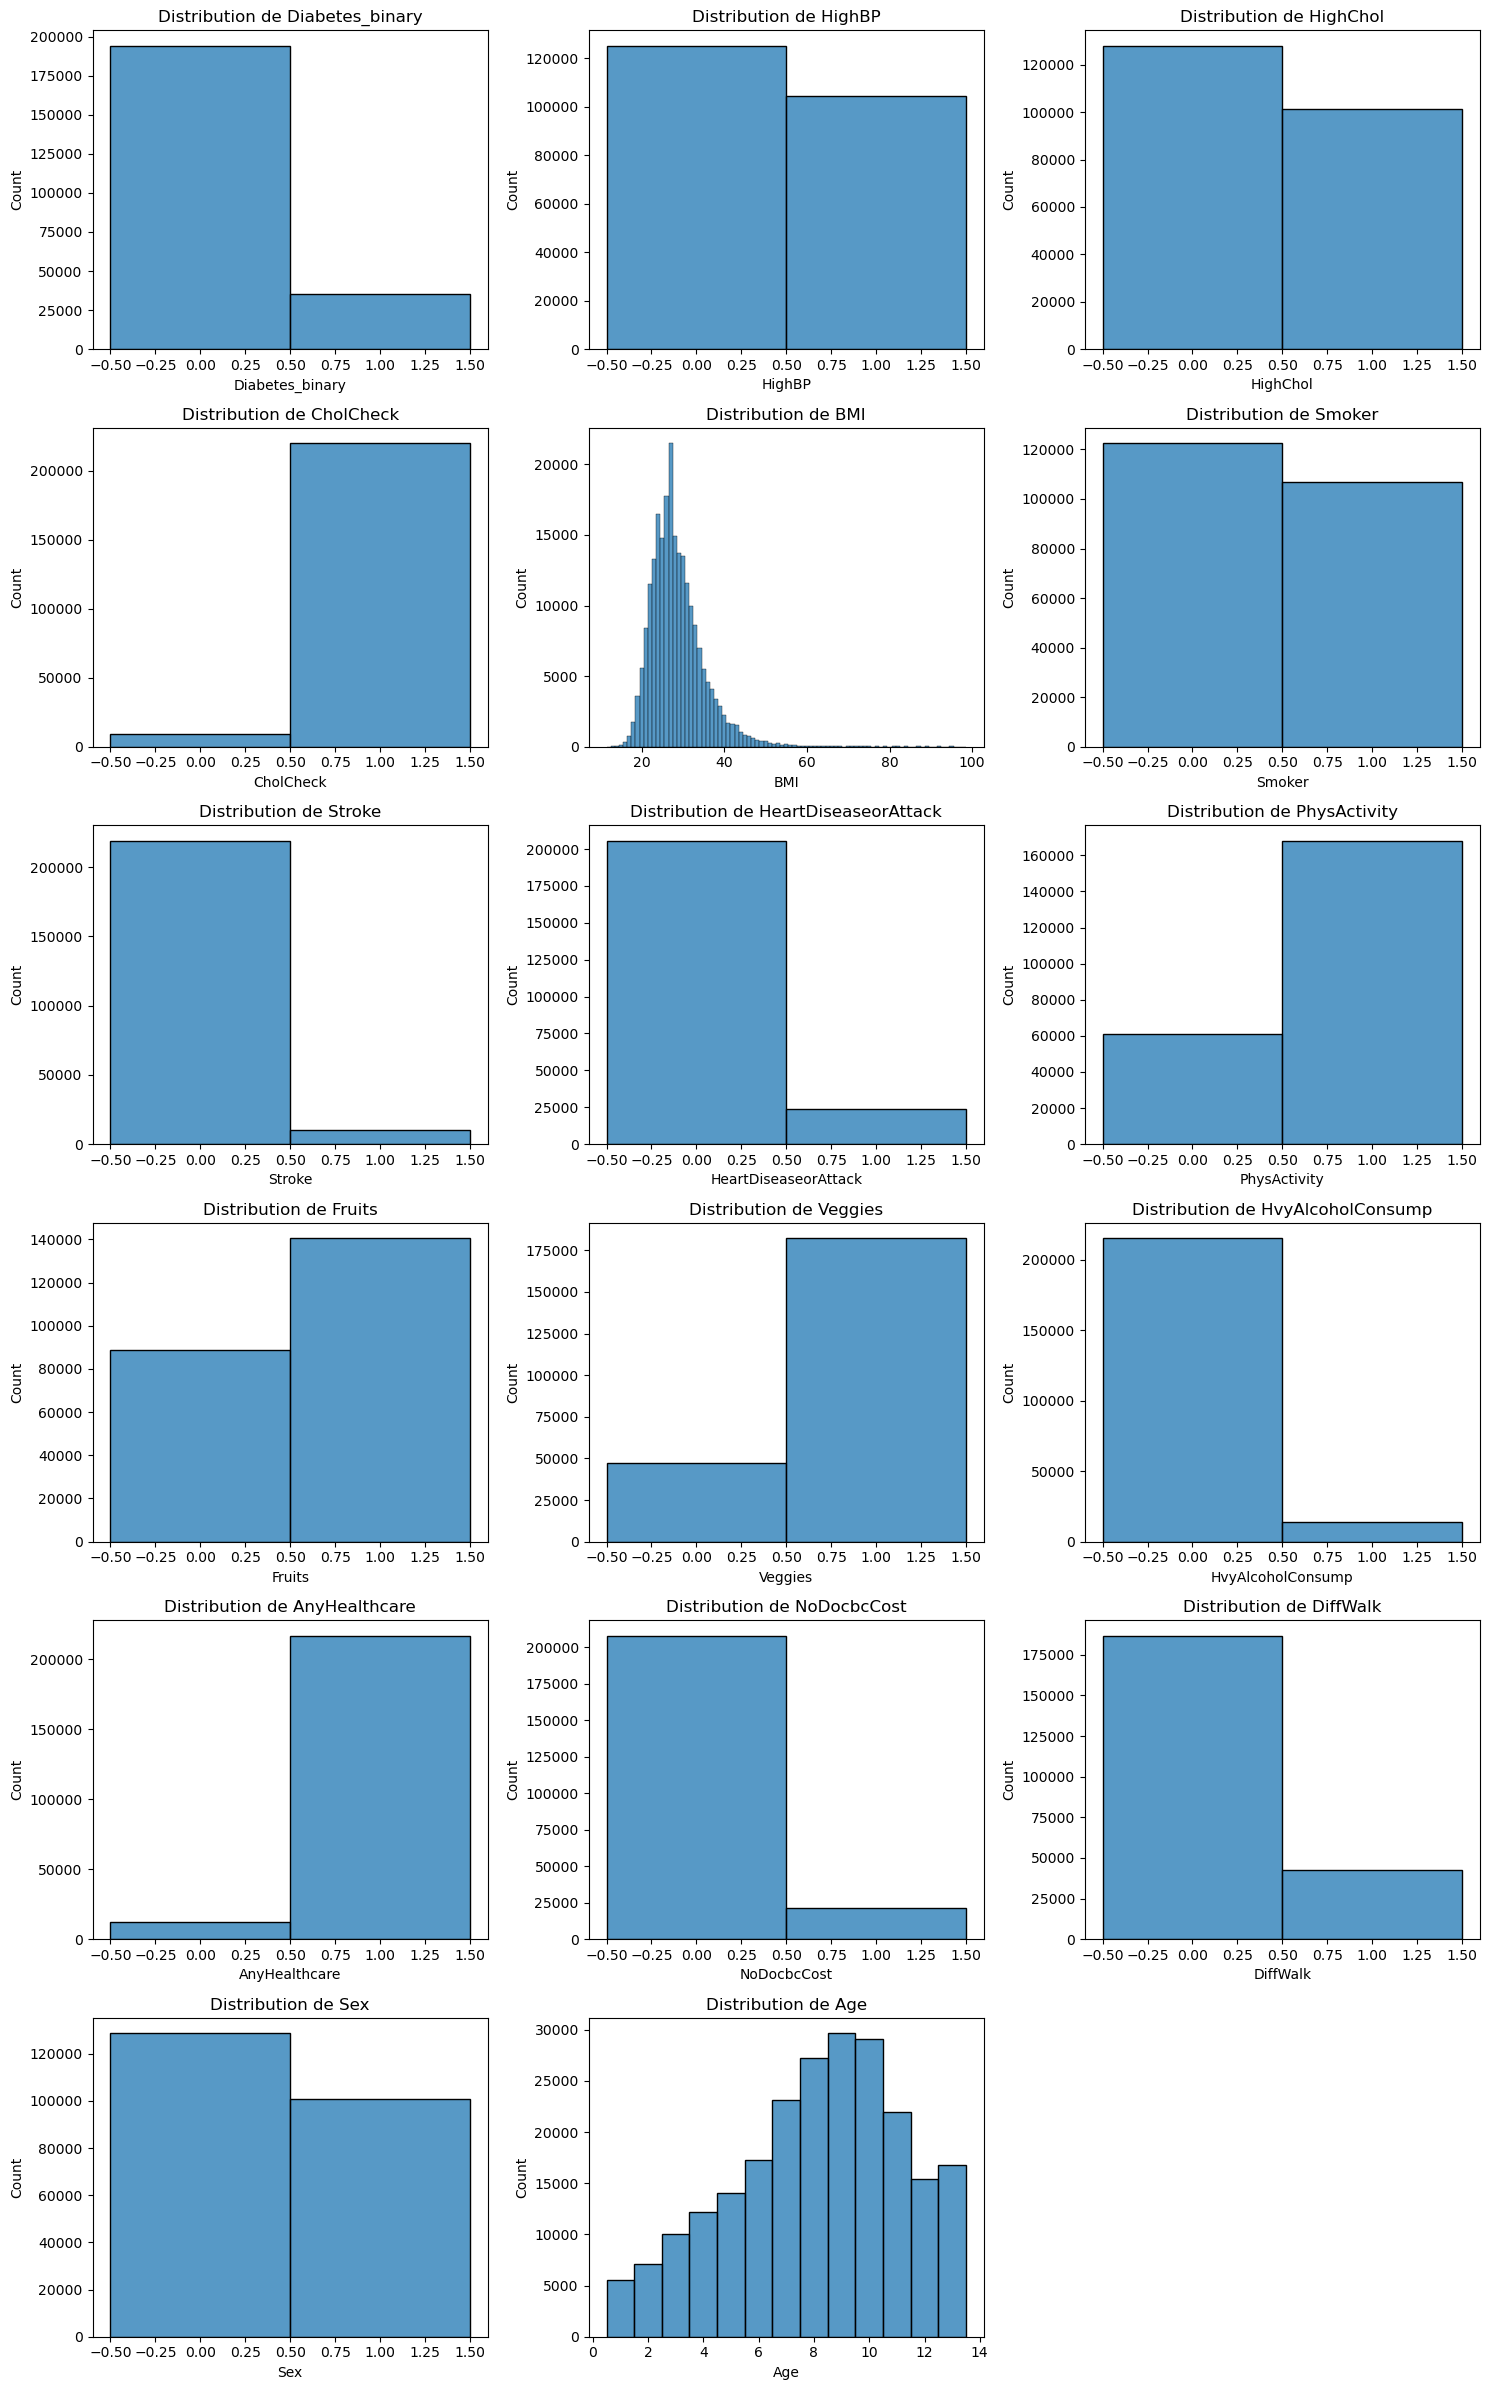

In [17]:
dataset.draw_distributions()

Comme notre seule variable quantitative est le BMI, c'est la seule pour laquelle nous devons vérifier la présence de données aberrantes.
On peut voir sur le graphique de distribution que la majorité des valeurs sont comprises entre 20 et 40, avec des valeurs allant jusqu'à 90.
La distribution de la variable BMI est donc très asymétrique.
De ce fait, nous orientons le choix de notre méthode de détection vers l'IQR, puisque celle-ci est adaptée aux distributions asymétriques.
Nous avons tout de même décidé de tester la méthode du Z-score comme c'est une des méthodes les plus utilisées.

### Application de la méthode de détection des valeurs aberrantes sur les données BMI

Afin de décider de la meilleure manière de normaliser les données nous avons tester deux méthodes de détection des valeurs aberrantes :
- Par z-score
- Par IQR

Pour le test, nous avons traiter les données aberrantes en les supprimant (trimming).

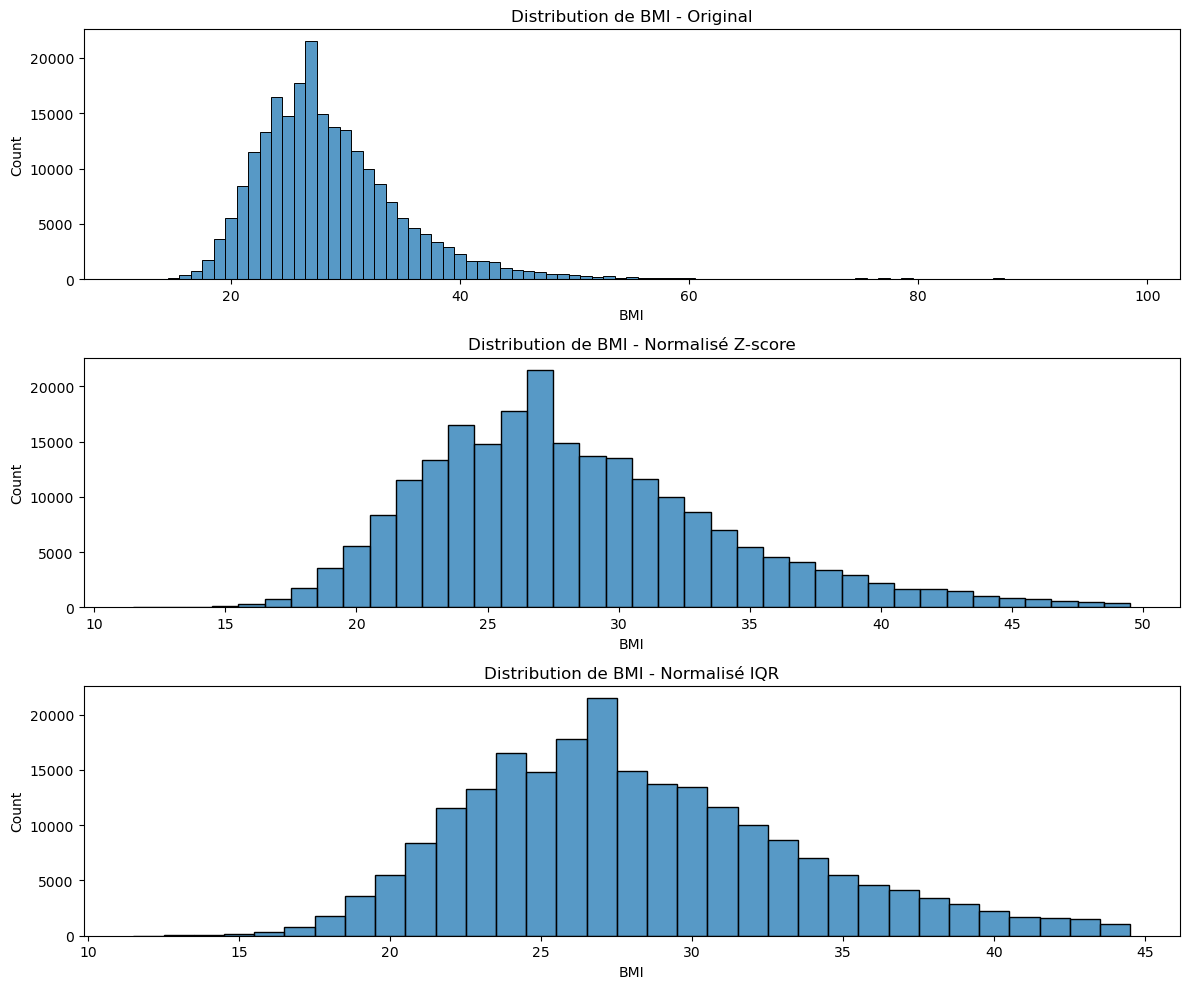

In [18]:
normalized_zscore_dataset = dataset.filter_outliers_zscore(column='BMI')
normalized_iqr_dataset = dataset.filter_outliers_iqr(column='BMI')

fig = plt.figure(figsize=(12, 10))

ax_original = fig.add_subplot(3, 1, 1)
ax_zscore = fig.add_subplot(3, 1, 2)
ax_iqr = fig.add_subplot(3, 1, 3)

dataset.draw_distribution(column='BMI', ax=ax_original, show = False)
normalized_zscore_dataset.draw_distribution(column='BMI', ax=ax_zscore, show = False)
normalized_iqr_dataset.draw_distribution(column='BMI', ax=ax_iqr, show = False)

ax_original.set_title("Distribution de BMI - Original")
ax_zscore.set_title("Distribution de BMI - Normalisé Z-score")
ax_iqr.set_title("Distribution de BMI - Normalisé IQR")

fig.tight_layout()
plt.show()

In [19]:
normalized_zscore_dataset.data['BMI'].describe()

count    226927.000000
mean         28.331274
std           5.792213
min          12.000000
25%          24.000000
50%          27.000000
75%          32.000000
max          49.000000
Name: BMI, dtype: float64

In [20]:
normalized_iqr_dataset.data['BMI'].describe()

count    223836.000000
mean         28.078263
std           5.411785
min          12.000000
25%          24.000000
50%          27.000000
75%          31.000000
max          44.000000
Name: BMI, dtype: float64

En comparaison la distribution des différents datasets après normalisation, on peut voir que la distribution des données est plus normale avec l'IQR que le z-score (écart-type de 5.79 contre 5.41).

Nous utiliserons donc la détection des valeurs aberrantes par l'IQR.

### Méthodes de gestion des valeurs aberrantes

Les différentes méthodes pour gérer les valeurs aberrantes dans un dataset sont les suivantes :

| Nom                     | Méthode                                                                                                              | Avantages                                                                                                            | Désavantages                                                                                       | Cas d'utilisation                                                                                          |
| ----------------------- | -------------------------------------------------------------------------------------------------------------------- | -------------------------------------------------------------------------------------------------------------------- | -------------------------------------------------------------------------------------------------- | ---------------------------------------------------------------------------------------------------------- |
| Suppression (trimming)  | On supprime entièrement les observation contenant la valeur aberrante                                                | Élimine complètement l’impact des outliers, Améliore certains modèles sensibles                                      | Perte d’information, Risque de biais si trop de données supprimées                                 | Données clairement erronées (erreurs de saisie), Dataset volumineux, Outliers très rares et non pertinents |
| Imputation              | On remplacer les valeurs aberrantes par la moyenne, la médiane, une valeur prédictive (avec un modèle de régression) | Conserve la taille du dataset, Méthode flexible (moyenne, médiane, modèles), Limite l’influence des valeurs extrêmes | Peut introduire du biais artificiel, Réduit la variabilité, Dépend fortement de la méthode choisie | Données manquantes ou aberrantes modérées, Besoin de conserver toutes les observations                     |
| Winsorisation (capping) | On remplace les valeurs extrêmes par des seuils (ex : 1er et 99e percentile).                                        | Limite l’influence des valeurs extrêmes, Conserve toutes les observations                                            | Déforme la distribution, Choix des seuils parfois arbitraire                                       | Données financières ou économiques, Présence d’outliers extrêmes mais plausibles                           |

In [21]:
outliers_number = dataset.get_row_count() - normalized_iqr_dataset.get_row_count()
outliers_percentage = (outliers_number / dataset.get_row_count()) * 100

print(f"Nombre de valeurs aberrantes : {outliers_number}")
print(f"Pourcentage de valeurs aberrantes : {outliers_percentage:.2f} %")

Nombre de valeurs aberrantes : 5638
Pourcentage de valeurs aberrantes : 2.46 %


On peut voir que seulement 2.46 % de nos lignes sont aberrantes en suivant la variable BMI.

De ce fait, il est possible d'utiliser la méthode de trimming pour les données de BMI aberrantes, ce qui évitera de créer trop de biais tout en perdant peu de données.

### Application de la méthode de gestion des valeurs aberrantes sur les données

Nous appliquons donc la méthode du trimming sur la colonne BMI de notre dataset :

In [22]:
dataset = dataset.filter_outliers_iqr(column='BMI')
dataset.data['BMI'].describe()

count    223836.000000
mean         28.078263
std           5.411785
min          12.000000
25%          24.000000
50%          27.000000
75%          31.000000
max          44.000000
Name: BMI, dtype: float64

## Normalisation

### Méthodes de normalisation

Les différentes méthodes de normalisation des données sont les suivantes :

| Nom                       | Méthode                                                                                      | Avantages                                                                                           | Désavantages                                                                              | Cas d'utilisation                                                                        |
| ------------------------- | -------------------------------------------------------------------------------------------- | --------------------------------------------------------------------------------------------------- | ----------------------------------------------------------------------------------------- | ---------------------------------------------------------------------------------------- |
| Z-score (standardisation) | Centrer les données autour de 0 et les réduire selon l’écart-type : $x'=(x−\mu)$             | Donne une distribution centrée sur 0 et comparable en variance ; Maintient la structure des données | Sensible aux outliers ; Nécessite une distribution proche de gaussienne pour être optimal | Modèles linéaires  <br>Méthodes basées sur la distance (k-NN, SVM)                       |
| Min-Max scaling           | Met les données dans un intervalle fixe (souvent [0,1]) : $x'=(x-x_{min})/(x_{max}-x_{min})$ | Utile pour les modèles sensibles à l’échelle                                                        | Dépend fortement des valeurs min et max observées (non robuste aux nouveaux extrêmes)     | Réseaux de neurones ; Données avec bornes naturelles connues                             |
| Robust scaling            | Utilise la médiane et l’IQR (intervalle interquartile) : $x'=(x-\text{médiane})/IQR$         | Stable pour des distributions asymétriques                                                          | Ne centre pas forcément les données à une moyenne nulle                                   | Données avec beaucoup d’outliers ; Données financières, biomédicales ou capteurs bruités |

Les deux méthodes les plus utilisées sont celles du Z-score et celle du Min-Max scaling. 

Nous allons donc essayer les deux sur nos données pour guider notre choix.

### Application des méthodes de normalisation

Text(0.5, 1.0, 'Normalisation Robust Scaling')

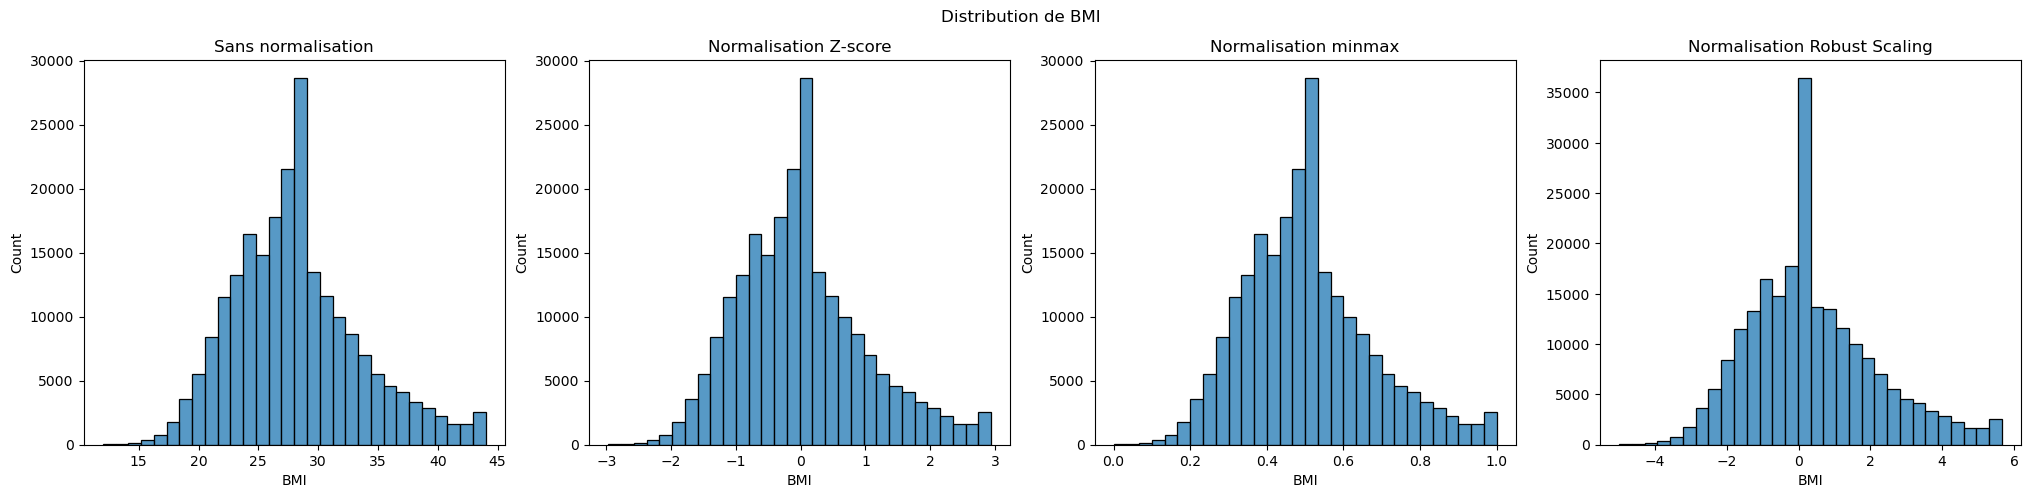

In [23]:
fig = plt.figure(figsize=(25, 5))

ax_original = fig.add_subplot(1, 4, 1)
ax_zscore = fig.add_subplot(1, 4, 2)
ax_minmax = fig.add_subplot(1, 4, 3)
ax_robust_scaling = fig.add_subplot(1, 4, 4)

zscore = dataset.normalize_zscore(['BMI'])
minmax = dataset.normalize_minmax(['BMI'])
robust_scaling = dataset.normalize_rubust_scaling(['BMI'])

dataset.draw_distribution(column='BMI', ax=ax_original, discrete=False, show=False)
zscore.draw_distribution(column='BMI', ax=ax_zscore, discrete=False, show=False)
minmax.draw_distribution(column='BMI', ax=ax_minmax, discrete=False, show=False)
robust_scaling.draw_distribution(column='BMI', ax=ax_robust_scaling, discrete=False, show=False)

fig.suptitle('Distribution de BMI')
ax_original.set_title("Sans normalisation")
ax_zscore.set_title("Normalisation Z-score")
ax_minmax.set_title("Normalisation minmax")
ax_robust_scaling.set_title("Normalisation Robust Scaling")

Pour la normalisation finale de nos données, nous allons utiliser la normalisation minmax, car elle nous permet de normaliser nos données entre les bornes 0 et 1, ce qui nous permet d'avoir les mêmes ordres de grandeur que nos variables binaires et ainsi de limiter le biais de notre modèle lié à la différence d'ordre de grandeur.

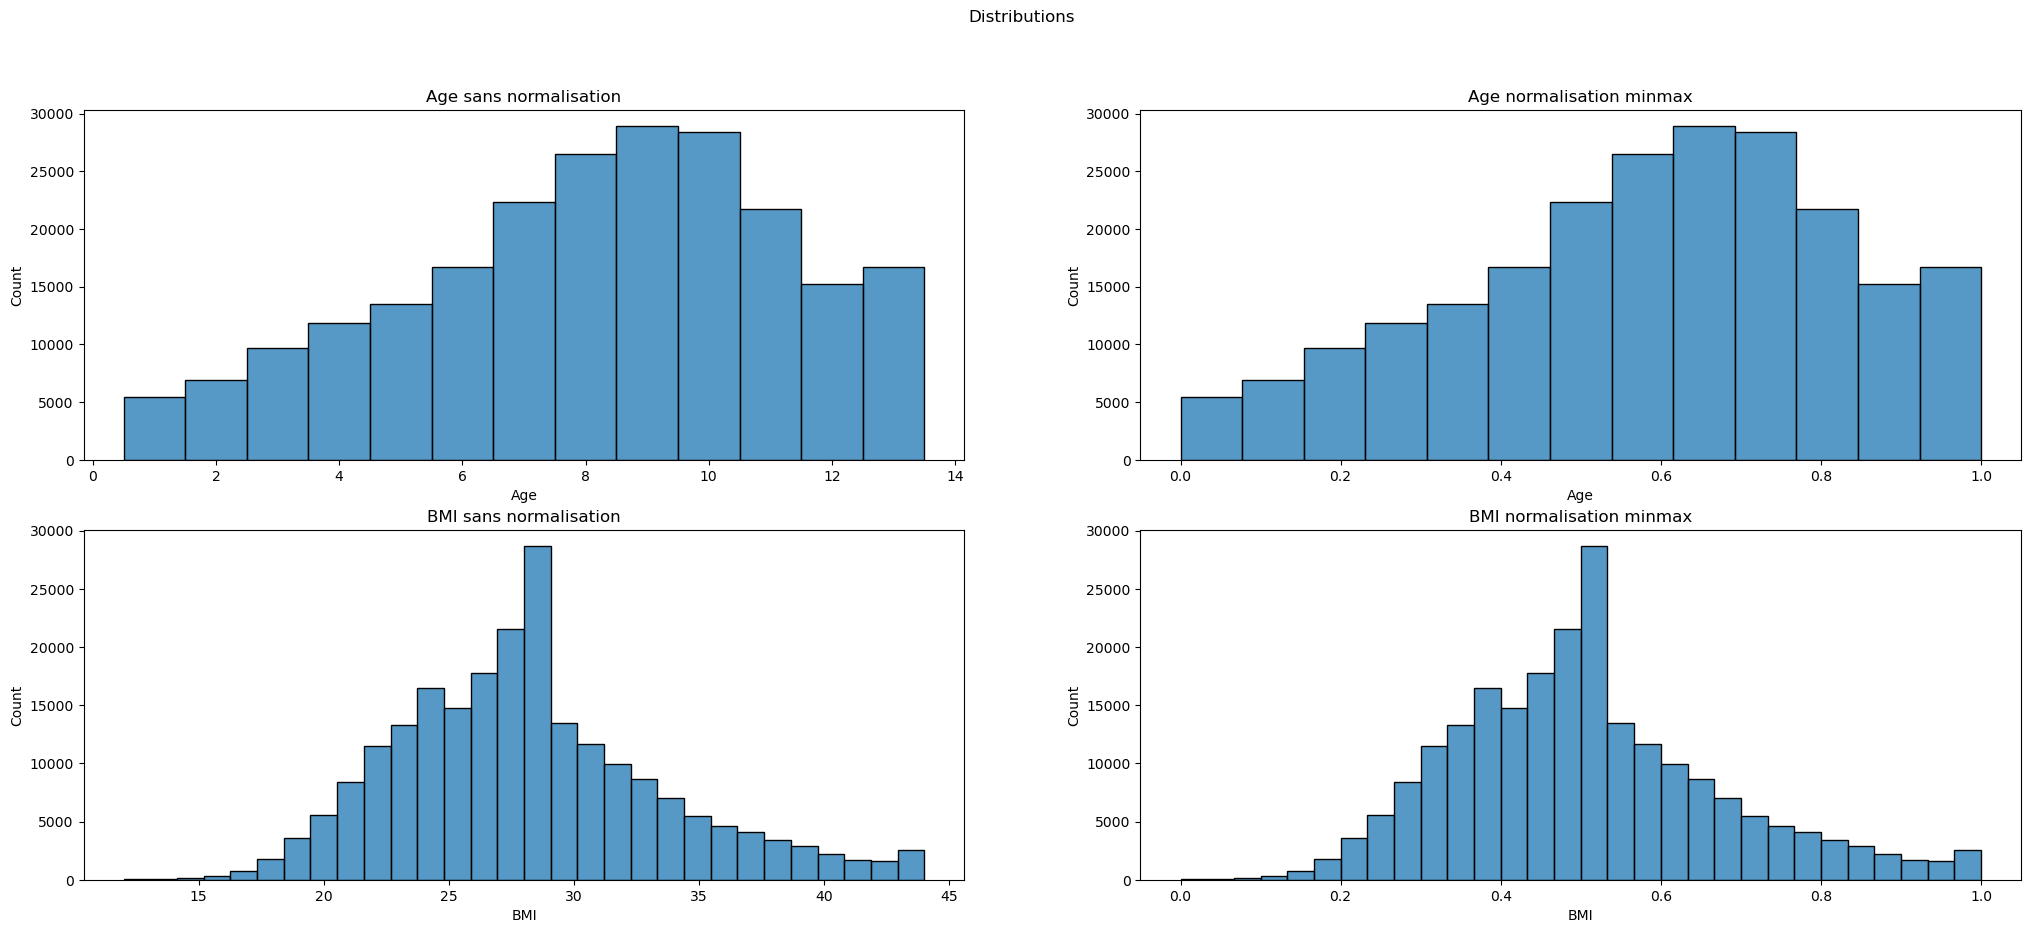

In [24]:
fig = plt.figure(figsize=(25, 10))

ax_age_original = fig.add_subplot(2, 2, 1)
ax_age_minmax = fig.add_subplot(2, 2, 2)

ax_BMI_original = fig.add_subplot(2, 2, 3)
ax_BMI_minmax = fig.add_subplot(2, 2, 4)

age_minmax = dataset.normalize_minmax(['Age'])
BMI_minmax = dataset.normalize_minmax(['BMI'])

dataset.draw_distribution(column='BMI', ax=ax_BMI_original, discrete=False, show=False)
BMI_minmax.draw_distribution(column='BMI', ax=ax_BMI_minmax, discrete=False, show=False, bins=30)
age_minmax.draw_distribution(column='Age', ax=ax_age_minmax, discrete=False, show=False, bins=13)
dataset.draw_distribution(column='Age', ax=ax_age_original, discrete=True, show=False)


fig.suptitle('Distributions')
ax_age_original.set_title("Age sans normalisation")
ax_age_minmax.set_title("Age normalisation minmax")
ax_BMI_original.set_title("BMI sans normalisation")
ax_BMI_minmax.set_title("BMI normalisation minmax")

dataset.data["BMI"] = BMI_minmax.data["BMI"]
dataset.data["Age"] = age_minmax.data["Age"]

On voit que la forme des distributions reste bien la même, mais est bornée entre 0 et 1. La normalisation par minmax a donc bien fonctionné.

## Analyse des corrélations

Afin d'estimer la corrélation entre les différentes variables et la variable cible, il existe plusieurs méthodes de corrélation. Ici, on en abordera 3 (méthodes disponibles dans la librairie Pandas) : 
- Pearson : mesure la force d'une relation linéaire entre deux variables continues. Cette méthode nécessite des variables avec une distribution normale pour correctement fonctionner. La valeur retournée est comprise entre $-1$ (corrélation négative parfaite) et $+1$ (corrélation positive parfaite). Un $0$ indique une absence totale de relation linéaire.
- Spearman : mesure la corrélation entre les évolutions respectives (augmentation et diminution respectives) de deux variables. Cette méthode à l'avantage d'être robuste aux valeurs aberrantes et de ne pas nécessiter de distribution normale.
- Kendall : Cette méthode utilise le même principe que Spearman, elle est cependant souvent considérée comme meilleure.

Nos données n'étant pas purement normalement distribuées, la méthode de pearson ne semble pas la plus appropriée. Nous avons toutefois comparé les trois méthodes ci-dessous.

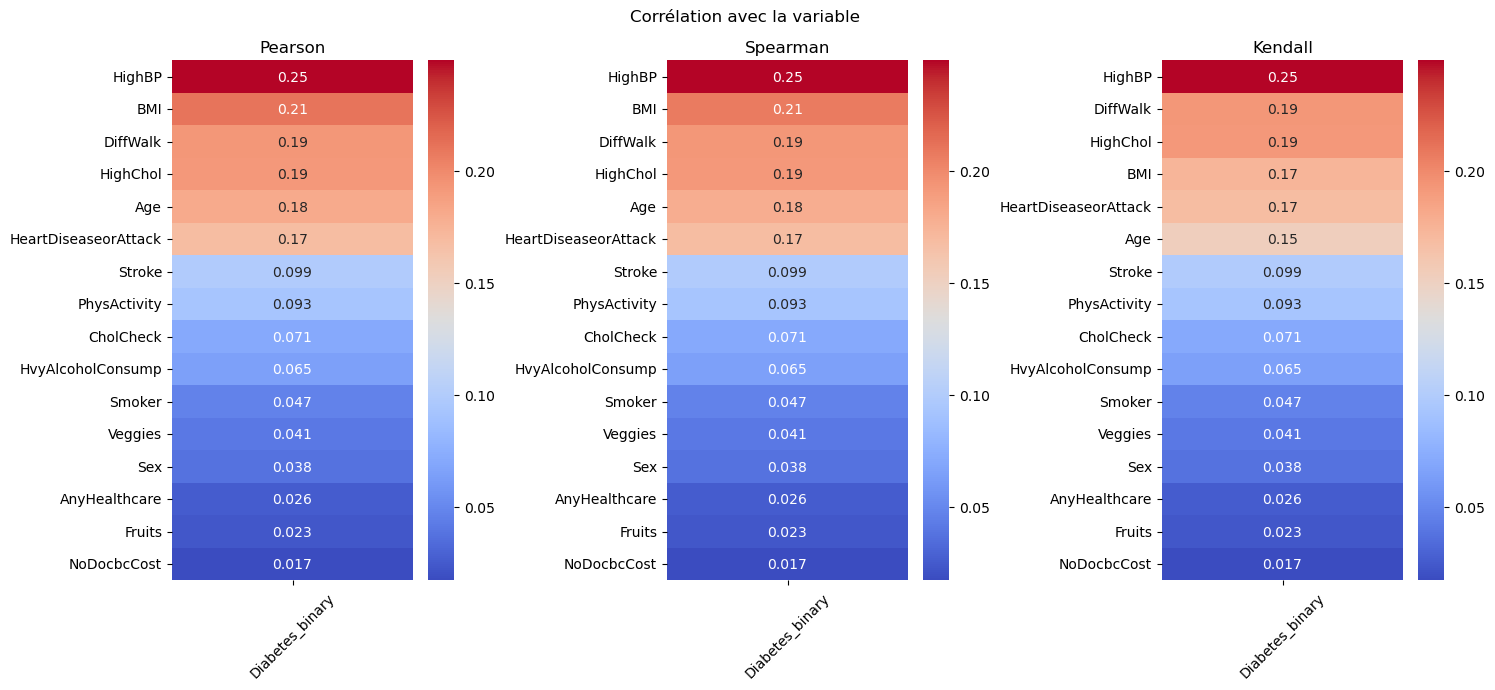

In [25]:
fig = plt.figure(figsize=(15, 7))

ax_pearson, ax_spearman, ax_kendall = fig.subplots(nrows=1, ncols=3)

dataset.draw_correlations_with_target(method='pearson', ax=ax_pearson, show=False)
dataset.draw_correlations_with_target(method='spearman', ax=ax_spearman, show=False)
dataset.draw_correlations_with_target(method='kendall', ax=ax_kendall, show=False)

fig.suptitle('Corrélation avec la variable')
ax_pearson.set_title('Pearson')
ax_spearman.set_title('Spearman')
ax_kendall.set_title('Kendall')

fig.tight_layout()
plt.show()

On constate que les trois méthodes donnent des résultats similaires. 

On constate également que 6 variables semblent bien plus corrélées à la variable cible que les autres : 
- Haute pression sanguine
- Indice de masse corporelle
- Difficulté à marcher et monter des marches
- Taux élevé de cholestérol
- Age
- Accident cardiaque

Cependant, nous n'exclurons pas de variable, car il n'y en a pas beaucoup (16). Ces variables représenteront des différentes entrées de notre réseau de neurones, il y aura donc 16 neurones dans la première couche de notre réseau de neurones. 

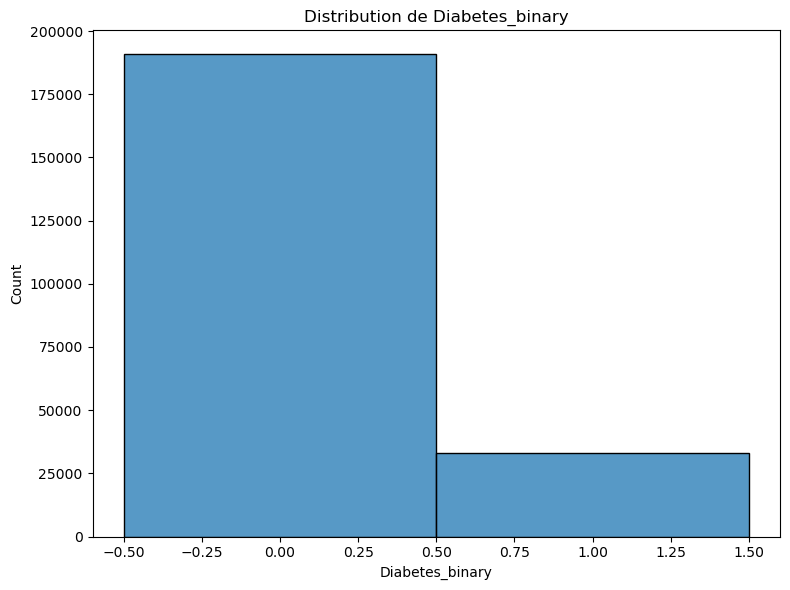

In [26]:
dataset.draw_distribution(column=dataset.target)

## Transformation finale

Création des jeux de données d'entraînement, de test et de validation.

Text(0.5, 1.0, 'Distribution des classes dans le validation')

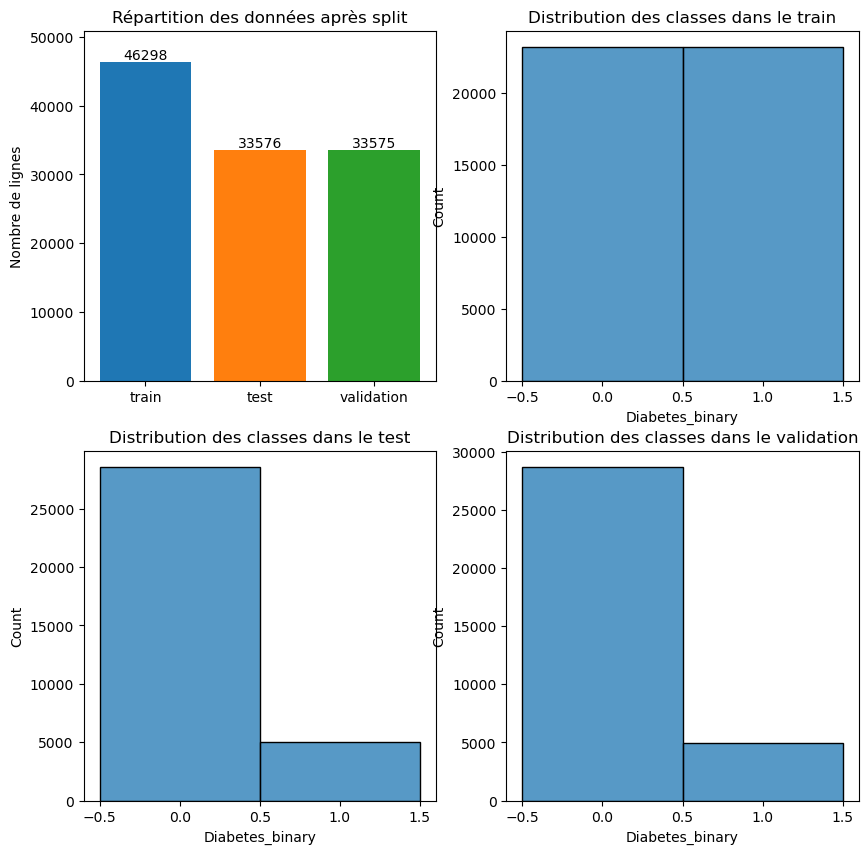

In [27]:
train_data, test_data, validation_data = dataset.export_to_csv("./dataset/dataset")

fig = plt.figure(figsize=(10, 10))
ax_split = fig.add_subplot(221)
ax_dist_train = fig.add_subplot(222)
ax_dist_test = fig.add_subplot(223)
ax_dist_val = fig.add_subplot(224)

repartition = {
    "train": len(train_data),
    "test": len(test_data),
    "validation": len(validation_data),
}
bars = ax_split.bar(repartition.keys(), repartition.values(), color=["tab:blue", "tab:orange", "tab:green"])
ax_split.set_title("Répartition des données après split")
ax_split.set_ylabel("Nombre de lignes")
ax_split.bar_label(bars)
ax_split.set_ylim(0, max(repartition.values()) * 1.1 if repartition.values() else 1)

sns.histplot(train_data[dataset.target], discrete=True, ax=ax_dist_train, binwidth=0.1)
ax_dist_train.set_title("Distribution des classes dans le train")
sns.histplot(test_data[dataset.target], discrete=True, ax=ax_dist_test, binwidth=0.1)
ax_dist_test.set_title("Distribution des classes dans le test")
sns.histplot(validation_data[dataset.target], discrete=True, ax=ax_dist_val, binwidth=0.1)
ax_dist_val.set_title("Distribution des classes dans le validation")

# Annexe

https://www.cdc.gov/brfss/annual_data/2024/pdf/2024-calculated-variables-version4-508.pdf